# Homework 2
### PSTAT 131/231

## Linear Regression and KNN
For this assignment, we will be working with a dataset from the UCI (University of California, Irvine) Machine Learning repository ([see website here](https://archive.ics.uci.edu/dataset/1/abalone)). The full dataset consists of 4,177 observations of abalone in Tasmania. (Fun fact: Tasmania supplies about 25\% of the yearly world abalone harvest.)


The age of an abalone is typically determined by cutting the shell open and counting the number of rings with a microscope. The purpose of this data set is to determine whether abalone age <b>(number of rings + 1.5)</b> can be accurately predicted using other, easier-to-obtain information about the abalone.

The full abalone data set is located in the \data subdirectory. Before moving on import the necessary libraries and load the data in using read_csv() like in homework #1. Take a moment to read through the codebook (abalone_codebook.txt) and familiarize yourself with the variable definitions.

### Scikit-Learn
We will be using Scikit-learn, sometimes reffered to as sklearn, to work with models like linear regression and k-nearest neighbors in python. Scikit-learn is a robust machine learning library that features various classification, regression and clustering algorithms. If you successfully followed the instructions for setting up the proper virtual environment, no further installation is necessary.

Due to the size of Scikit-learn, when importing the library we import specific modules or functions. Since this is the first assignment using Scikit-learn, the importing is already handeled below. Once you've gotten a look at how Scikit-learn imports are handled, import pandas, numpy, matplotlib.pyplot and seaborn with the usual alias'.

In [3]:
# Here we import the classes and functions we'll use in this assignment from sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

# Import numpy, pandas, matplotlib.pyplot and seaborn with the usual alias'. Then read in the data. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



np.random.seed(42)

abalone_data = pd.read_csv("/Users/clee/Desktop/PSTAT_131/homework-2-python/data/abalone.csv")
abalone_data.head(2)

,type,longest_shell,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.15,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.07,7


## Setting Up Data

### Question 1
Your goal is to predict abalone age, which is calculated as the number of rings plus 1.5. Notice there currently is no age variable in the data set. Add an age column to the dataframe `abalone_data` then describe the distribution of age. To describe the distribution you can use a seaborn histogram, boxplot or some summary statistics.

* Adding new columns to a dataframe is relatively easy, here are some [examples](https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html) in the pandas documentation. 

count    4177.000000
mean       11.433684
std         3.224169
min         2.500000
25%         9.500000
50%        10.500000
75%        12.500000
max        30.500000
Name: age, dtype: float64


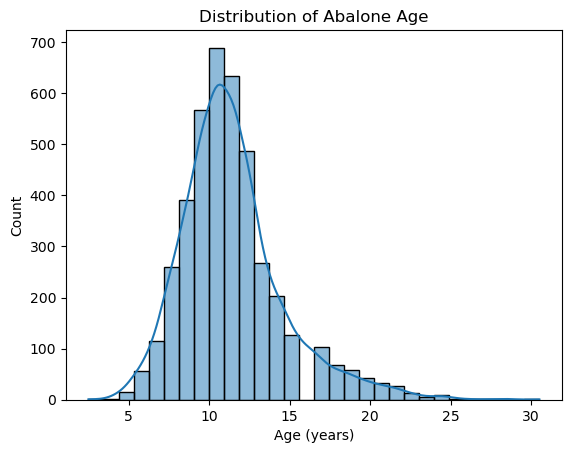

In [6]:
# Create a new column called 'age' in abalone data
abalone_data['age'] = abalone_data['rings'] + 1.5

# Once the column has been created describe the distribution
print(abalone_data['age'].describe())


#claude LLM was used here for extra visuals
sns.histplot(data=abalone_data, x='age', bins=30, kde=True)
plt.title('Distribution of Abalone Age')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

**Description of the distribution:**

The age of abalone from this data ranges from 2.5 to 30.5 years. The mean is about 11.4 years and a median of 10.5 years. The distribution is right-skewed (positively skewed): most abalone are between roughly 8 and 13 years old, but there is a long right tail of older abalone extending past 20 years. Because the mean exceeds the median, the skew is confirmed numerically. The standard deviation is about 3.2 years.

### Question 2 
Split the abalone data into training and testing splits with stratified sampling. You should decide on appropriate percentages for splitting the data. In sklearn this can be done with [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) which we imported above. Stratified sampling in sklearn requires us to filter out any elements of the stratified variable that occur once. As removing variables that only occur once isn't entirely intuitive the code to remove any necessary elements can be found in the below chunk. Pay special attention to what it is doing and then create training and testing splits with [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [7]:
# Here we remove any elements in age that only occur once.
abalone_age_counts = abalone_data['age'].value_counts() # Get the counts of our variables in the age column
abalone_data = abalone_data[abalone_data['age'].isin(abalone_age_counts[abalone_age_counts > 1].index)] # Use the counts as a mask to only take ages that appear more than once.

In [8]:
# 80/20 train-test split
abalone_train, abalone_test = train_test_split(
    abalone_data,
    test_size=0.2,
    stratify=abalone_data['age'],
    random_state=42
)
print('Training set shape:', abalone_train.shape)
print('Testing set shape:', abalone_test.shape)

Training set shape: (3337, 10)
Testing set shape: (835, 10)


## Setting Up Model Objects

In Scikit-learn in order to use models like k-nearest neighbors and linear regression, we initialize several different objects which are imported above. 

These objects have different methods, ones we use later are shown below:

* [.fit()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit) fits the model with our training data.
* [.predict()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict) allows us to put in new data and get predictions.

### Question 3
Create a linear regression model object using the class we imported earlier.

In [9]:
# Create the linear_model with an sklearn import.
linear_model = LinearRegression()

### Question 4
Create a KNN model object using the class we imported earlier. Specify n_neighbors = 7.

In [10]:
# Create the knn_model with an sklearn import.
knn_model = KNeighborsRegressor(n_neighbors=7)

## Preparing Our Data
Similarly to R, we'll need to transform our data prior to using machine learning models like linear regression. This process varies from task to task but for this assignment we will be dummy coding categorical variables and centering and scaling our data. Unlike in R with Tidyverse, the option to create a recipe in python is not straightforward. While this does mean slightly more work, it also means we have more control over what is happening step by step.


### Question 5 
Create a function to pre-process the data prior to modelling. Take note that the data going into this function will not include rings and age. Below your function, explain why you shouldn't use rings to predict age. 

To center and scale our variables in Scikit-learn we will be using [StandardScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler). Like linear regression and k-nearest neighbors model objects, standard scalar has its state modified once fitted with data. Because of this, the object must be saved after fitting training data in order to re-use it on separate examples or testing data. To handle this, initialize the standard scalar object outside of the function and use booleans to determine if you fit data to the scalar or not.

What your pre-process function should do in order:
* Dummy code any categorical predictors with [pd.get_dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), utilize the dtype parameter so that your dummy coded predictors are numerical. 

* Create interactions between
    * `type` and `shucked_weight`
    * `longest_shell` and `diameter`
    * `shucked_weight` and `shell_weight`

* Center and scale all predictors with [StandardScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

**Hint**: When creating interaction terms that categorical variables get dummy coded into several columns, for these predictors you may want to use a for loop or write out individual cases. 



In [ ]:
# Import and initialize StandardScalar from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

def preprocess(abalone_data : pd.DataFrame, is_training : bool) -> pd.DataFrame:
    """
    Takes in abalone data and prepares it for usage in k-nearest neighbors and linear regression models
    by dummy coding variables, creating interaction terms and centering and scaling all predictors.

    Args:
        abalone_data (pd.DataFrame) : The pandas dataframe containing the abalone dataset.
        is_training (bool) :  A boolean that signifies if the scalar needs to be fit or not.
    Returns:
        abalone_processed (pd.DataFrame) : The processed abalone dataset, ready for modelling.
    """

    # We make a copy of the abalone_predictors dataframe to avoid modifying the original dataframe
    abalone_processed = abalone_data.copy()

    # Preprocess data
    # 1) Dummy code the categorical predictor 'type' as numeric (float) columns.
    abalone_processed = pd.get_dummies(abalone_processed, columns=['type'], dtype=float)

    # 2) Interaction between 'type' and 'shucked_weight'.
    #    Since 'type' is now several dummy columns, we loop over them.
    for col in ['type_F', 'type_I', 'type_M']:
        if col in abalone_processed.columns:
            abalone_processed[f'{col}_x_shucked_weight'] = (
                abalone_processed[col] * abalone_processed['shucked_weight']
            )

    # 3) Interaction between 'longest_shell' and 'diameter'.
    abalone_processed['longest_shell_x_diameter'] = (
        abalone_processed['longest_shell'] * abalone_processed['diameter']
    )

    # 4) Interaction between 'shucked_weight' and 'shell_weight'.
    abalone_processed['shucked_weight_x_shell_weight'] = (
        abalone_processed['shucked_weight'] * abalone_processed['shell_weight']
    )

    # Standard_scalar returns a numpy array, which we combine with column names to make a dataframe again.
    column_names = abalone_processed.columns

    # Scale and center predictors. Only fit when training; otherwise reuse fitted scaler.
    if is_training:
        abalone_processed = scaler.fit_transform(abalone_processed)
    else:
        abalone_processed = scaler.transform(abalone_processed)

    # We return a Dataframe 
    return pd.DataFrame(abalone_processed, columns = column_names)

#Claude LLM was used here to help preprocess the data for the models. 

**Why shouldn't rings be included?**

Age is defined as `rings + 1.5`, so rings is a deterministic linear function of the response. Including it as a predictor would be data leakage. This is because the model could achieve essentially perfect predictions just by reading off the rings column, which trivializes the problem and tells us nothing about whether age can be predicted from the easier-to-obtain physical measurements (the whole point of this dataset). It would also make any "learned" coefficient on the other predictors essentially zero, masking the actual relationships of interest.

## Fitting Models

### Question 6
Now, for each of these models (linear regression and KNN):

1. Store the age column of the dataset in a separate variable called `abalone_train_outcome`.
2. Drop the age and rings column using [.drop()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html).
1. Apply the preprocessing function you created earlier to the training dataset.
3. Fit the model using the models [.fit()]() method

In [15]:
# Store the age column.
abalone_train_outcome = abalone_train['age'].reset_index(drop=True)

# Drop age and rings from the predictors.
abalone_train_predictors = abalone_train.drop(columns=['age', 'rings']).reset_index(drop=True)

# Preprocess the data.
abalone_train_new = preprocess(abalone_train_predictors, is_training=True)
abalone_train_new.head(2)

,longest_shell,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type_F,type_I,type_M,type_F_x_shucked_weight,type_I_x_shucked_weight,type_M_x_shucked_weight,longest_shell_x_diameter,shucked_weight_x_shell_weight
0,0.175039,0.425352,0.279586,-0.096982,0.093195,-0.164214,-0.163642,-0.673348,-0.687487,1.313043,-0.592375,-0.532598,0.889009,0.210019,-0.259481
1,0.467698,0.526395,0.408807,0.418603,0.496298,0.380577,0.403115,-0.673348,-0.687487,1.313043,-0.592375,-0.532598,1.249435,0.438538,0.212773


In [16]:
# Fit the linear and knn models, setting the X and y parameters accordingly.
linear_model.fit(abalone_train_new, abalone_train_outcome)
knn_model.fit(abalone_train_new, abalone_train_outcome)

KNeighborsRegressor(n_neighbors=7)

### Question 6
Use your linear_model object to predict the age of 3 abalone as described below. Remember that you need to preprocess data, the data needs to be in the form of a dataframe and your preprocess function assumes you do not have rings and age columns.

The 3 abalone we will predict:
* a hypothetical female abalone with longest_shell = 0.50, diameter = 0.10, height = 0.30, whole_weight = 4, shucked_weight = 1, viscera_weight = 2, and shell_weight = 1.
* a hypothetical male abalone with longest_shell = 0.70, diameter = 0.15, height = 0.34, whole_weight = 6, shucked_weight = 2, viscera_weight = 3, and shell_weight = 1.
* a hypothetical infant abalone with longest_shell = 0.25, diameter = 0.5, height = 0.20, whole_weight = 3, shucked_weight = 0.5, viscera_weight = 1, and shell_weight = 0.5.


In [17]:
# Build a dataframe of the 3 hypothetical abalone (no rings, no age).
hypothetical = pd.DataFrame({
    'type':           ['F',  'M',  'I'],
    'longest_shell':  [0.50, 0.70, 0.25],
    'diameter':       [0.10, 0.15, 0.50],
    'height':         [0.30, 0.34, 0.20],
    'whole_weight':   [4,    6,    3],
    'shucked_weight': [1,    2,    0.5],
    'viscera_weight': [2,    3,    1],
    'shell_weight':   [1,    1,    0.5],
})

# Preprocess using the already-fitted scaler (is_training=False).
hypothetical_processed = preprocess(hypothetical, is_training=False)

# Predict ages.
predicted_ages = linear_model.predict(hypothetical_processed)
for label, age in zip(['Female', 'Male', 'Infant'], predicted_ages):
    print(f'Predicted age of hypothetical {label} abalone: {age:.2f} years')

Predicted age of hypothetical Female abalone: 25.57 years
Predicted age of hypothetical Male abalone: 20.58 years
Predicted age of hypothetical Infant abalone: 31.69 years


## Assessing Performance
Now we want to assess our models performance, luckily for us Scikit-learn has some functions we can use for that!

### Question 7
Figure out how to import the following functions from [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics): $R^2$, RMSE (root mean squared error) and MAE (mean absolute error). Then get predictions from both linear and knn models and place them in the imported functions along with the testing data. Report the results and then interpret the $R^2$ value.

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prepare the test set the same way as the training set, but DO NOT refit the scaler.
abalone_test_outcome = abalone_test['age'].reset_index(drop=True)
abalone_test_predictors = abalone_test.drop(columns=['age', 'rings']).reset_index(drop=True)
abalone_test_new = preprocess(abalone_test_predictors, is_training=False)

# Get predictions from both models.
linear_preds = linear_model.predict(abalone_test_new)
knn_preds    = knn_model.predict(abalone_test_new)

# Compute metrics. RMSE = sqrt(MSE).
results = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN (k=7)'],
    'R^2':  [r2_score(abalone_test_outcome, linear_preds),
             r2_score(abalone_test_outcome, knn_preds)],
    'RMSE': [np.sqrt(mean_squared_error(abalone_test_outcome, linear_preds)),
             np.sqrt(mean_squared_error(abalone_test_outcome, knn_preds))],
    'MAE':  [mean_absolute_error(abalone_test_outcome, linear_preds),
             mean_absolute_error(abalone_test_outcome, knn_preds)],
})
results

,Model,R^2,RMSE,MAE
0,Linear Regression,0.519105,2.179267,1.541795
1,KNN (k=7),0.497818,2.226977,1.562532


**Interpretation of $R^2$:**

$R^2$ is the proportion of the variance in age that is explained by the model. A value near 1 indicates the predictors explain almost all of the variation in age, while 0 indicates the model does no better than predicting the mean. For the linear model, $R^2 \approx 0.52$, means roughly 52% of the variability in abalone age is explained by the physical measurements (and their interactions). The remaining ~48% is unexplained. This could be that some of that is genuine noise, and some is structure that the linear model cannot capture (the relationship between rings and physical size flattens for older abalone). The KNN model with $k=7$ produces a similar but slightly lower $R^2$, indicating comparable but somewhat weaker predictive performance on this test set.

### Question 9
*Which model performed better on the testing data? Explain why you think this might be. Are you surprised by any of your results? Why or why not?*

Linear regression did a little better than KNN on the test set because it had a higher R² (0.519 vs 0.498) and lower errors too. I think this happened because we ended up with 15 predictors after adding all the dummy variables and interaction terms. KNN doesn't really do well when there are that many features. It just looks at which points are "closest," but with so many dimensions and a bunch of variables that basically measure the same thing (like length, diameter, and the different weights), the idea of "closest" gets kind of weird. Linear regression handles that better because it can give each variable its own weight. I'm not really surprised that they were close though, since neither R² is that high (only about 52%), which probably just means you can't perfectly predict an abalone's age from its size. Older abalone don't keep growing much, so there's a limit to how good any model can do here. Also we just picked k = 7 without testing other values, so KNN might've done better if we tuned it.